<a href="https://colab.research.google.com/github/FuzzilyDeveloper/rna_seq/blob/main/RNAseq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/GSE183947_fpkm.csv/GSE183947_fpkm.csv'
df = pd.read_csv(file_path)
print(df.head())

  Unnamed: 0  CA.102548  CA.104338  CA.105094  CA.109745  CA.1906415  \
0     TSPAN6       0.93       1.97       0.00       5.45        4.52   
1       TNMD       0.00       0.00       0.00       0.00        0.00   
2       DPM1       0.00       0.43       0.00       3.43        8.45   
3      SCYL3       5.78       5.17       8.76       4.58        7.20   
4   C1orf112       2.83       6.26       3.37       6.24        5.16   

   CA.1912627  CA.1924346  CA.1926760  CA.1927842  ...  CAP.2040686  \
0        4.75        3.96        3.58        6.41  ...         6.66   
1        0.00        0.00        0.23        0.39  ...         0.12   
2        8.53        7.80        7.62        6.40  ...         4.93   
3        6.03        9.05        5.37        5.92  ...         8.02   
4       13.69        6.69        5.28        7.65  ...         7.91   

   CAP.2046297  CAP.2046641  CAP.348981  CAP.354300  CAP.359448  CAP.94377  \
0         8.35         8.94        6.33        5.94        6.3

In [ ]:
df = df.T
print(df.head())

             0     1     2      3         4     5     6      7      8      \
Unnamed: 0  TSPAN6  TNMD  DPM1  SCYL3  C1orf112   FGR   CFH  FUCA2   GCLC   
CA.102548     0.93   0.0   0.0   5.78      2.83   4.8  1.37  21.92  34.16   
CA.104338     1.97   0.0  0.43   5.17      6.26  1.83  1.78  10.48  25.12   
CA.105094      0.0   0.0   0.0   8.76      3.37   0.0   0.0    0.0  21.77   
CA.109745     5.45   0.0  3.43   4.58      6.24  4.23  2.59  23.78  16.48   

            9      ...       20236         20237         20238         20239  \
Unnamed: 0   NFYA  ...  CTB-96E2.2  CTC-432M15.3  RP11-986E7.7  RP11-761B3.1   
CA.102548     0.7  ...         0.0           0.0           0.0           0.0   
CA.104338    1.13  ...         0.0           0.0           0.1          0.03   
CA.105094     0.0  ...         0.0           0.0           0.0           0.0   
CA.109745   10.72  ...         0.0           0.0          1.15           0.0   

             20240          20241         20242     2024

In [ ]:
df['sample_type'] = df.index.astype(str).map(lambda x: 'normal' if x.strip().startswith('CAP') else ('tumor' if x.strip().startswith('CA') else 'unknown'))

print("DataFrame with 'sample_type' column added:")
display(df.head())

DataFrame with 'sample_type' column added:


,0,1,2,3,4,5,6,7,8,9,...,20237,20238,20239,20240,20241,20242,20243,20244,20245,sample_type
Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1,unknown
CA.102548,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,0.7,...,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0,tumor
CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0,tumor
CA.105094,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,0.0,...,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0,tumor
CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0,tumor


In [ ]:
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,20237,20238,20239,20240,20241,20242,20243,20244,20245,sample_type
Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1,unknown
CA.102548,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,0.7,...,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0,tumor
CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0,tumor
CA.105094,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,0.0,...,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0,tumor
CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0,tumor


In [ ]:
# The user wants to set the column names using the values from the row with index 'Unnamed: 0'.
# This row contains the gene identifiers.
# Additionally, the DataFrame's index should be named 'Sample_ID', and the column axis 'Gene'.

# Step 1: Extract gene names from the 'Unnamed: 0' row.
# This row also contains a 'sample_type' value which is not a gene name, so we drop it before creating the new column list.
if 'Unnamed: 0' in df.index:
    # Get all values from the 'Unnamed: 0' row.
    header_row_values = df.loc['Unnamed: 0']

    # Separate the gene names from the 'sample_type' value.
    # Use errors='ignore' in case 'sample_type' was already moved or not present in this specific row.
    gene_names = header_row_values.drop('sample_type', errors='ignore').tolist()

    # The last column is 'sample_type', which needs to be retained as a column name.
    # So, the new columns will be the gene names followed by 'sample_type'.
    new_columns = gene_names + ['sample_type']

    # Step 2: Set these as the new column names for the DataFrame.
    df.columns = new_columns

    # Step 3: Remove the 'Unnamed: 0' row from the DataFrame as it's now redundant.
    df = df.drop(index='Unnamed: 0')

    # Step 4: Name the DataFrame's index 'Sample_ID'.
    df.index.name = 'Sample_ID'

    # Step 5: Name the DataFrame's column axis 'Gene'.
    df.columns.name = 'Gene'

    print("DataFrame successfully corrected. Displaying the head:")
    display(df.head())
else:
    print("Error: The 'Unnamed: 0' row, expected to contain column names, was not found.")
    print("Current DataFrame head:")
    display(df.head())

DataFrame successfully corrected. Displaying the head:


Gene,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1,sample_type
Sample_ID,,,,,,,,,,,,,,,,,,,,,
CA.102548,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,0.7,...,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0,tumor
CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0,tumor
CA.105094,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,0.0,...,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0,tumor
CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0,tumor
CA.1906415,4.52,0.0,8.45,7.2,5.16,15.87,9.21,14.95,18.19,17.5,...,0.0,0.0,0.0,4.69,0.0,0.0,0.0,0.64,0.0,tumor


In [ ]:
df.columns.name = None
print("DataFrame after removing 'Gene' from column axis name:")
display(df.head())

DataFrame after removing 'Gene' from column axis name:


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1,sample_type
Sample_ID,,,,,,,,,,,,,,,,,,,,,
CA.102548,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,0.7,...,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0,tumor
CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0,tumor
CA.105094,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,0.0,...,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0,tumor
CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0,tumor
CA.1906415,4.52,0.0,8.45,7.2,5.16,15.87,9.21,14.95,18.19,17.5,...,0.0,0.0,0.0,4.69,0.0,0.0,0.0,0.64,0.0,tumor


In [ ]:
df = df.reset_index()

display(df.head())

,Sample_ID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1,sample_type
0,CA.102548,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,...,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0,tumor
1,CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,...,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0,tumor
2,CA.105094,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,...,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0,tumor
3,CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,...,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0,tumor
4,CA.1906415,4.52,0.0,8.45,7.2,5.16,15.87,9.21,14.95,18.19,...,0.0,0.0,0.0,4.69,0.0,0.0,0.0,0.64,0.0,tumor


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define y as the target variable (sample_type)
y = df['sample_type']

# Define X as the feature matrix (all columns except sample_type and Sample_ID)
X = df.drop(columns=['sample_type', 'Sample_ID'])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

Shape of X: (60, 20246)
Shape of y: (60,)

First 5 rows of X:


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTB-96E2.2,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1
0,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,0.7,...,0.0,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0
1,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,0.0,...,0.0,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0
3,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0
4,4.52,0.0,8.45,7.2,5.16,15.87,9.21,14.95,18.19,17.5,...,0.0,0.0,0.0,0.0,4.69,0.0,0.0,0.0,0.64,0.0



First 5 values of y:


,sample_type
0,tumor
1,tumor
2,tumor
3,tumor
4,tumor


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define y as the target variable (sample_type)
y = df['sample_type']

# Define X as the feature matrix (all columns except sample_type and Sample_ID)
X = df.drop(columns=['sample_type', 'Sample_ID'])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

# Step 1: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame for easier handling, keeping Sample_ID
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Shape of scaled data X_scaled_df:", X_scaled_df.shape)

# Step 2: Apply PCA
pca = PCA(n_components=4) # Let's start with 2 principal components for now
X_pca = pca.fit_transform(X_scaled_df)

# Dynamically generate column names for the PCA results
pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=pca_columns, index=X.index)

# Add the 'sample_type' information to the PCA DataFrame
pca_df['sample_type'] = y

print("Variance explained by PC1 and PC2:", pca.explained_variance_ratio_)
print("Cumulative variance explained by PC1 and PC2:", pca.explained_variance_ratio_.sum())

print("\nFirst 5 rows of PCA results (pca_df):")
display(pca_df.head())

Shape of X: (60, 20246)
Shape of y: (60,)

First 5 rows of X:


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTB-96E2.2,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1
0,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,0.7,...,0.0,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0
1,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,0.0,...,0.0,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0
3,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0
4,4.52,0.0,8.45,7.2,5.16,15.87,9.21,14.95,18.19,17.5,...,0.0,0.0,0.0,0.0,4.69,0.0,0.0,0.0,0.64,0.0



First 5 values of y:


,sample_type
0,tumor
1,tumor
2,tumor
3,tumor
4,tumor


Shape of scaled data X_scaled_df: (60, 20246)
Variance explained by PC1 and PC2: [0.21153076 0.09554894 0.07347373 0.06623433]
Cumulative variance explained by PC1 and PC2: 0.4467877596132979

First 5 rows of PCA results (pca_df):


,PC1,PC2,PC3,PC4,sample_type
0,51.028353,107.846502,-55.531304,12.302789,tumor
1,32.897639,89.617455,-48.279294,10.207596,tumor
2,93.495687,164.087330,-51.368338,7.925226,tumor
3,-17.602298,19.242519,-30.995241,13.856381,tumor
4,-18.659358,15.996175,-13.530777,4.516697,tumor


In [ ]:
from scipy import stats

# Separate PCA scores by sample type
tumor_pca = pca_df[pca_df['sample_type'] == 'tumor'].drop(columns=['sample_type'])
normal_pca = pca_df[pca_df['sample_type'] == 'normal'].drop(columns=['sample_type'])

print("T-test results for each Principal Component:")
for pc_col in pca_df.columns[:-1]: # Iterate through all PC columns, excluding 'sample_type'
    t_stat, p_val = stats.ttest_ind(tumor_pca[pc_col], normal_pca[pc_col])
    print(f"\n{pc_col}:")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_val:.4f}")

    # Interpret p-value (common alpha = 0.05)
    if p_val < 0.01:
        print("  The difference between tumor and normal groups for this PC is statistically significant (p < 0.05).")
    else:
        print("  The difference between tumor and normal groups for this PC is not statistically significant (p >= 0.05).")

T-test results for each Principal Component:

PC1:
  T-statistic: -2.9027
  P-value: 0.0052
  The difference between tumor and normal groups for this PC is statistically significant (p < 0.05).

PC2:
  T-statistic: 1.6336
  P-value: 0.1077
  The difference between tumor and normal groups for this PC is not statistically significant (p >= 0.05).

PC3:
  T-statistic: -5.5735
  P-value: 0.0000
  The difference between tumor and normal groups for this PC is statistically significant (p < 0.05).

PC4:
  T-statistic: 3.2296
  P-value: 0.0020
  The difference between tumor and normal groups for this PC is statistically significant (p < 0.05).


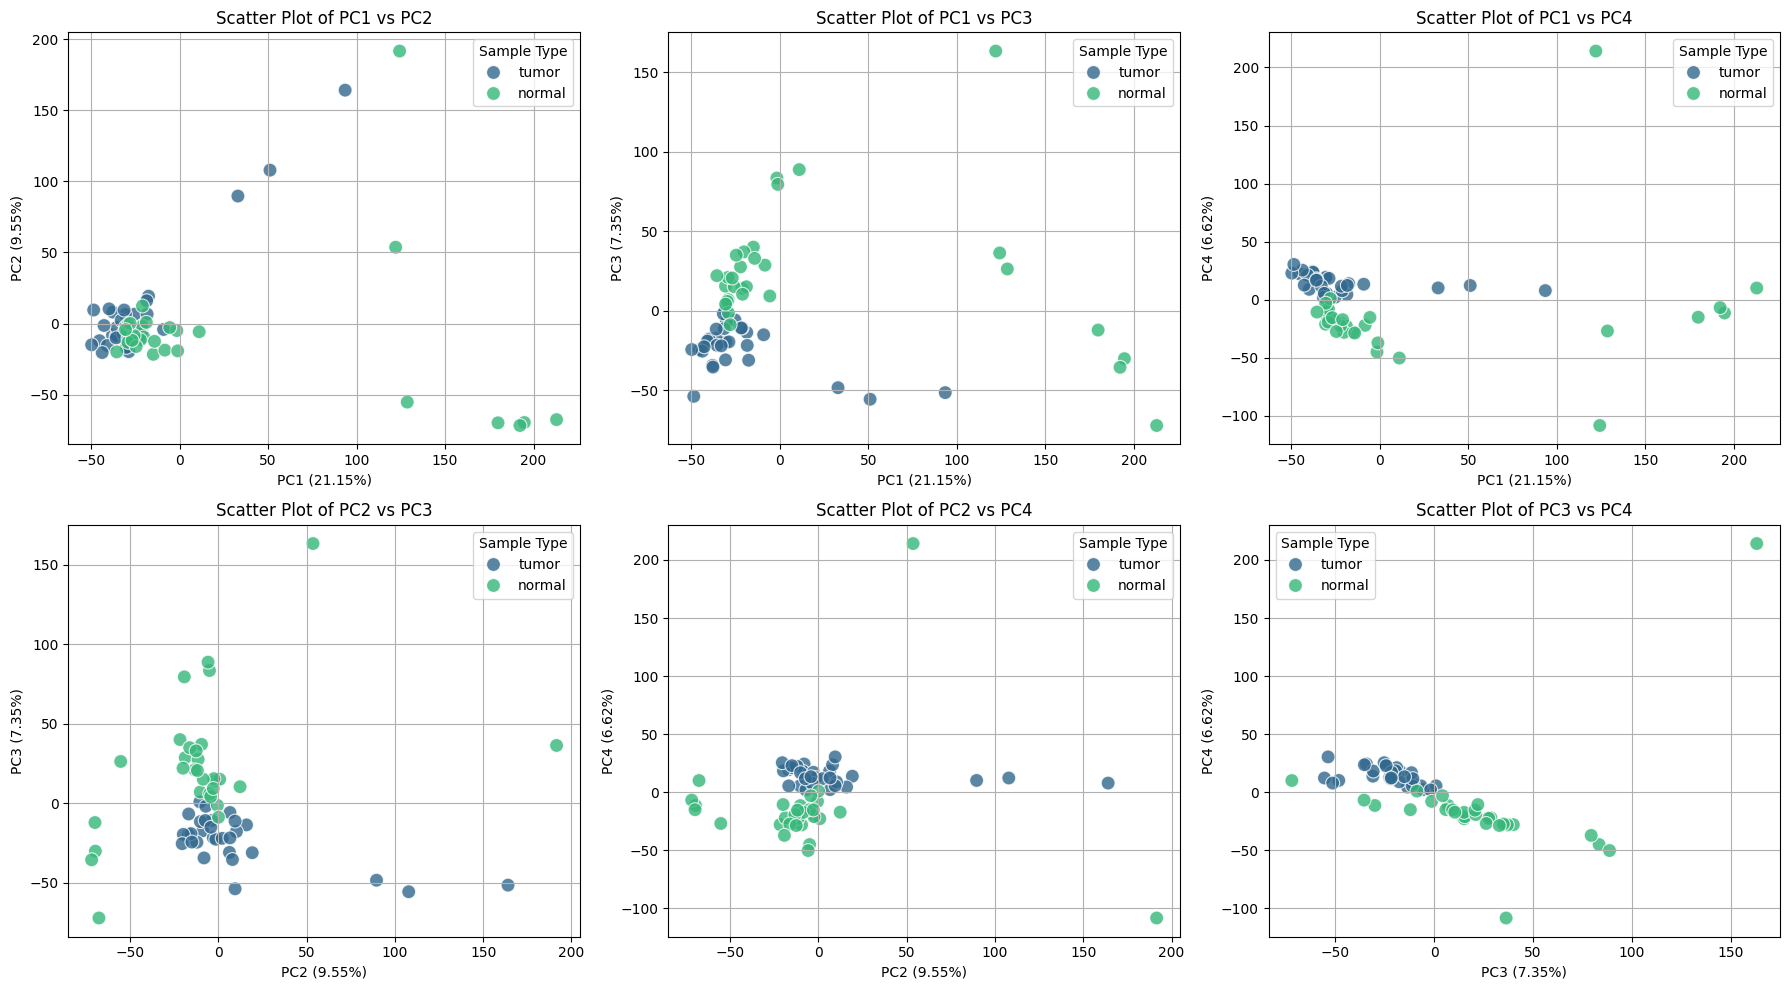

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Get the principal component column names
pc_cols = [col for col in pca_df.columns if col.startswith('PC')]

# Generate all unique pairs of principal components
pc_pairs = list(itertools.combinations(pc_cols, 2))

# Create a figure with subplots for each pair
# Determine grid size. For 6 plots, a 2x3 or 3x2 grid works well.
num_rows = 2
num_cols = 3

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, (pc_x, pc_y) in enumerate(pc_pairs):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(
        x=pc_x, y=pc_y, hue='sample_type', data=pca_df,
        palette='viridis', s=100, alpha=0.8
    )
    # Add variance explained to axis labels for more context
    pc_x_index = int(pc_x[2:]) - 1 # Extract PC number and convert to 0-based index
    pc_y_index = int(pc_y[2:]) - 1
    plt.xlabel(f'{pc_x} ({pca.explained_variance_ratio_[pc_x_index]*100:.2f}%)')
    plt.ylabel(f'{pc_y} ({pca.explained_variance_ratio_[pc_y_index]*100:.2f}%)')
    plt.title(f'Scatter Plot of {pc_x} vs {pc_y}')
    plt.legend(title='Sample Type')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assuming X and y are already defined from previous steps
# X: feature matrix (gene expression data)
# y: target variable (sample_type)

# Standardize the features before applying LDA
scaler_lda = StandardScaler()
X_scaled_lda = scaler_lda.fit_transform(X)

# Apply LDA
# For binary classification, n_components is typically 1
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled_lda, y)

# Create a DataFrame for LDA results
lda_df = pd.DataFrame(data=X_lda, columns=['LD1'], index=X.index)

# Add the 'sample_type' information to the LDA DataFrame
lda_df['sample_type'] = y

print("LDA results (first 5 rows):")
display(lda_df.head())

print("\nExplained variance ratio by LD1:")
print(lda.explained_variance_ratio_)


LDA results (first 5 rows):


,LD1,sample_type
0,3.199499,tumor
1,3.304448,tumor
2,3.018035,tumor
3,2.625803,tumor
4,2.848947,tumor



Explained variance ratio by LD1:
[1.]


In [ ]:
import pandas as pd

# The coefficients (importance scores) for each feature in the LDA model
# lda.coef_ is typically a 2D array, even for a single component, so we take the first row.
ld_coefficients = lda.coef_[0]

# Create a DataFrame to display the coefficients with their corresponding feature names
# Assuming X.columns holds the original feature names
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'LD1_Coefficient': ld_coefficients
})

# Sort the features by the absolute value of their coefficients to see the most important ones
coefficients_df['Abs_Coefficient'] = coefficients_df['LD1_Coefficient'].abs()
coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("Top 10 features contributing to LD1 (by absolute coefficient value):")
display(coefficients_df.head(10))

print("\nBottom 10 features contributing to LD1 (by absolute coefficient value):")
display(coefficients_df.tail(10))

Top 10 features contributing to LD1 (by absolute coefficient value):


,Feature,LD1_Coefficient
18702,DEFB130,-0.240261
19547,TRIM6-TRIM34,0.054368
17355,TMEM244,0.039774
18715,AC104794.4,0.036663
19413,CCDC177,-0.033897
14707,CDRT1,-0.032323
19982,AC110615.1,-0.031037
3204,PTN,-0.029688
6144,VCY1B,-0.029519
6145,VCY,-0.029519



Bottom 10 features contributing to LD1 (by absolute coefficient value):


,Feature,LD1_Coefficient
19585,TSPY1,0.0
19063,RBMY1D,0.0
18208,AC007952.1,0.0
18206,AC005493.1,0.0
18476,AC096644.1,0.0
18284,AL138815.1,0.0
18261,AL135998.1,0.0
18271,AC015989.1,0.0
18479,GAGE12H,0.0
20242,RP11-944L7.5,0.0


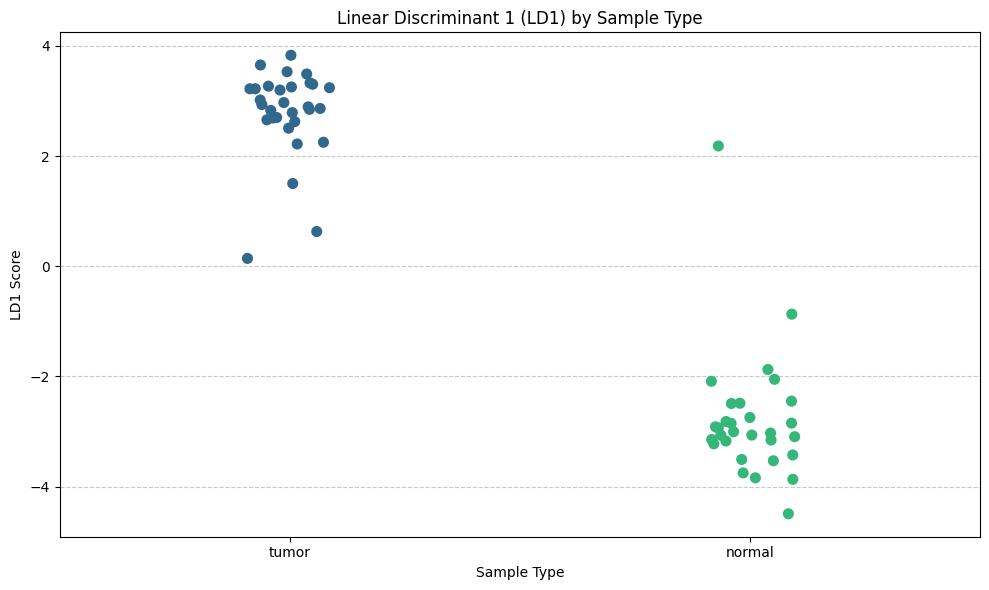

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.stripplot(x='sample_type', y='LD1', data=lda_df, hue='sample_type', palette='viridis', jitter=True, size=8)
plt.title('Linear Discriminant 1 (LD1) by Sample Type')
plt.xlabel('Sample Type')
plt.ylabel('LD1 Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Removed redundant plt.legend() as seaborn's stripplot with hue typically handles it
plt.tight_layout()
plt.show()

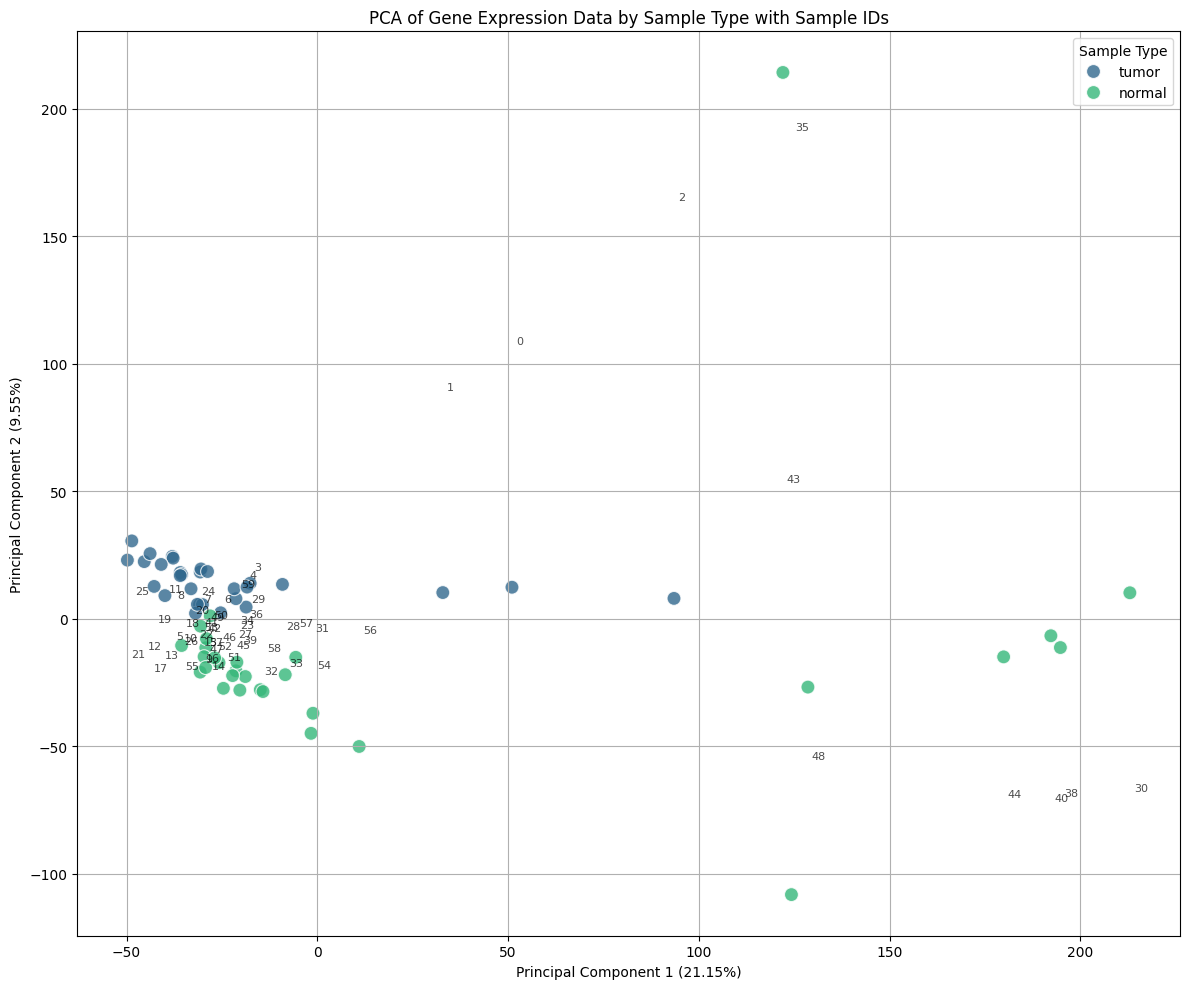

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='PC1', y='PC4', hue='sample_type', data=pca_df,
    palette='viridis', s=100, alpha=0.8
)

# Annotate each point with its Sample_ID
for i, row in pca_df.iterrows():
    plt.text(row['PC1'] + 1, row['PC2'], str(pca_df.index[i]), fontsize=8, alpha=0.7)

plt.title('PCA of Gene Expression Data by Sample Type with Sample IDs')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend(title='Sample Type')
plt.tight_layout()
plt.show()

In [ ]:
df.shape

(60, 20248)

In [ ]:
y = df['sample_type']
# X will have Sample_ID as its index as 'sample_type' is the only column being dropped
X = df.drop(columns=['sample_type'])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (60, 20247)
Shape of y: (60,)


In [ ]:
print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head(60))


First 5 rows of X:


,Sample_ID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,CTB-96E2.2,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1
0,CA.102548,0.93,0.0,0.0,5.78,2.83,4.8,1.37,21.92,34.16,...,0.0,0.0,0.0,0.0,38.27,0.0,0.0,0.0,0.0,0.0
1,CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,...,0.0,0.0,0.1,0.03,30.99,0.16,0.0,0.0,0.0,0.0
2,CA.105094,0.0,0.0,0.0,8.76,3.37,0.0,0.0,0.0,21.77,...,0.0,0.0,0.0,0.0,47.57,0.0,0.0,0.0,0.0,0.0
3,CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,...,0.0,0.0,1.15,0.0,12.27,0.0,0.0,0.83,0.1,0.0
4,CA.1906415,4.52,0.0,8.45,7.2,5.16,15.87,9.21,14.95,18.19,...,0.0,0.0,0.0,0.0,4.69,0.0,0.0,0.0,0.64,0.0



First 5 values of y:


,sample_type
0,tumor
1,tumor
2,tumor
3,tumor
4,tumor
5,tumor
6,tumor
7,tumor
8,tumor
9,tumor


In [ ]:
from sklearn.model_selection import train_test_split

# Perform the train-test split with stratification to ensure both classes are present
X_train, X_test, y_train, y_test = train_test_split(pca_df, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\ny_train value counts:")
print(y_train.value_counts())
print("\ny_test value counts:")
print(y_test.value_counts())

X_train shape: (48, 5)
X_test shape: (12, 5)
y_train shape: (48,)
y_test shape: (12,)

y_train value counts:
sample_type
tumor     24
normal    24
Name: count, dtype: int64

y_test value counts:
sample_type
normal    6
tumor     6
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier
# X_train should only contain numerical features, so drop the 'sample_type' column
rf_classifier.fit(X_train.drop(columns=['sample_type']), y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

# Drop 'sample_type' from X_test to match the features used during training
y_pred = rf_classifier.predict(X_test.drop(columns=['sample_type']))

score = accuracy_score(y_test,y_pred )

print(f"Accuracy Score: {score}")

Accuracy Score: 0.9166666666666666


In [ ]:
import pandas as pd

# Combine actual and predicted values into a DataFrame for clear display
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

print("\nActual vs. Predicted values:")
display(results_df)


Actual vs. Predicted values:


,Actual,Predicted
40,normal,normal
28,tumor,tumor
14,tumor,tumor
36,normal,normal
15,tumor,tumor
44,normal,normal
9,tumor,tumor
37,normal,normal
25,tumor,tumor
49,normal,normal
